In [1]:
import torch 
import torchvision


In [2]:
import os 
from pathlib import Path

data_path = Path('oxford-iiit-pet')

for dirpath, dirnames, filenames in os.walk(data_path) : 
    print(f'# of directories : {len(dirnames)} and {len(filenames)} images in {dirpath}')



# of directories : 2 and 2 images in oxford-iiit-pet
# of directories : 2 and 5 images in oxford-iiit-pet\annotations
# of directories : 0 and 14780 images in oxford-iiit-pet\annotations\trimaps
# of directories : 0 and 3686 images in oxford-iiit-pet\annotations\xmls
# of directories : 0 and 7393 images in oxford-iiit-pet\images


In [3]:
weights = torchvision.models.MobileNet_V3_Small_Weights.DEFAULT

auto_transforms = weights.transforms()

In [4]:
auto_transforms # Resize value is 256 

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [5]:
train_data = torchvision.datasets.OxfordIIITPet(
    root = '' , 
    split = 'trainval' ,
    download = True , 
    transform = auto_transforms
)
test_data = torchvision.datasets.OxfordIIITPet(
    root = '' ,
    split = 'test' , 
    download = True , 
    transform = auto_transforms
)

In [6]:
class_names = train_data.classes

class_names[:5] # It's a long list first five elements is enough for confirm.

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle']

In [7]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset = train_data ,
    batch_size = 64 , 
    shuffle = True , 
    pin_memory = torch.cuda.is_available() 
)
test_dataloader = DataLoader(
    dataset = test_data , 
    batch_size = 64 ,
    shuffle = True ,
    pin_memory = torch.cuda.is_available() 
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.465708].


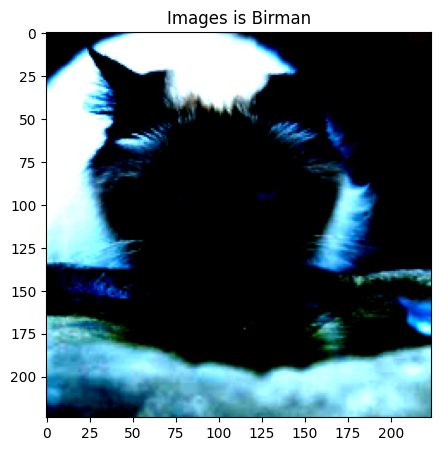

In [8]:
import matplotlib.pyplot as plt
def plot_images(dataloader : DataLoader , data_num : int , class_names : list) :
    images , labels = next(iter(dataloader))
    
    img = images[data_num].permute(1 , 2 , 0)
    label = labels[data_num]

    plt.figure(figsize = (5 , 5))
    plt.imshow(img)
    plt.title(f'Images is {class_names[label]}')
    plt.show()

plot_images(train_dataloader , data_num = 2 , class_names = class_names)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = torchvision.models.mobilenet_v3_small(weights = weights).to(device)

model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [10]:
from torchinfo import summary

summary(model = model , input_size = [32 , 3 , 256 , 256] , col_names = ['output_size' , 'num_params' , 'trainable'])

Layer (type:depth-idx)                             Output Shape              Param #                   Trainable
MobileNetV3                                        [32, 1000]                --                        True
├─Sequential: 1-1                                  [32, 576, 8, 8]           --                        True
│    └─Conv2dNormActivation: 2-1                   [32, 16, 128, 128]        --                        True
│    │    └─Conv2d: 3-1                            [32, 16, 128, 128]        432                       True
│    │    └─BatchNorm2d: 3-2                       [32, 16, 128, 128]        32                        True
│    │    └─Hardswish: 3-3                         [32, 16, 128, 128]        --                        --
│    └─InvertedResidual: 2-2                       [32, 16, 64, 64]          --                        True
│    │    └─Sequential: 3-4                        [32, 16, 64, 64]          744                       True
│    └─InvertedResidual: 

In [11]:
# the model has 1000 output but ı just wanna len(class_names) numbers output 
# i am going to modify linear layer output.

In [12]:
for params in model.features.parameters() : 
    params.requires_grad = False

summary(model = model , input_size = [32 , 3 , 256 , 256] , col_names = ['input_size' , 'num_params' , 'trainable'])

Layer (type:depth-idx)                             Input Shape               Param #                   Trainable
MobileNetV3                                        [32, 3, 256, 256]         --                        Partial
├─Sequential: 1-1                                  [32, 3, 256, 256]         --                        False
│    └─Conv2dNormActivation: 2-1                   [32, 3, 256, 256]         --                        False
│    │    └─Conv2d: 3-1                            [32, 3, 256, 256]         (432)                     False
│    │    └─BatchNorm2d: 3-2                       [32, 16, 128, 128]        (32)                      False
│    │    └─Hardswish: 3-3                         [32, 16, 128, 128]        --                        --
│    └─InvertedResidual: 2-2                       [32, 16, 128, 128]        --                        False
│    │    └─Sequential: 3-4                        [32, 16, 128, 128]        (744)                     False
│    └─InvertedR

In [13]:
from torch import nn

class_names = train_data.classes

model.classifier[3] = nn.Linear(in_features = 1024 , out_features = len(class_names) , bias = True).to(device)

summary(model = model , input_size = [32 , 3 , 256 , 256] , col_names = ['input_size' , 'num_params' , 'trainable'])

Layer (type:depth-idx)                             Input Shape               Param #                   Trainable
MobileNetV3                                        [32, 3, 256, 256]         --                        Partial
├─Sequential: 1-1                                  [32, 3, 256, 256]         --                        False
│    └─Conv2dNormActivation: 2-1                   [32, 3, 256, 256]         --                        False
│    │    └─Conv2d: 3-1                            [32, 3, 256, 256]         (432)                     False
│    │    └─BatchNorm2d: 3-2                       [32, 16, 128, 128]        (32)                      False
│    │    └─Hardswish: 3-3                         [32, 16, 128, 128]        --                        --
│    └─InvertedResidual: 2-2                       [32, 16, 128, 128]        --                        False
│    │    └─Sequential: 3-4                        [32, 16, 128, 128]        (744)                     False
│    └─InvertedR

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters() , lr = 0.001 )

In [38]:
from torchmetrics.classification import MulticlassAccuracy

def train_step(
        model : nn.Module ,
        dataset : torch.utils.data.DataLoader , 
        loss_fn : nn.Module , 
        optimizer : torch.optim.Optimizer , 
        device 
) : 
    
    model.train()

    train_loss , train_acc = 0 , 0 
    correct_predictions = 0
    total_samples = 0
    num_batches = len(dataset)

    for X , y in dataset :
        X , y = X.to(device) , y.to(device)

        y_pred_logits = model(X)

        loss = loss_fn(y_pred_logits , y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_labels = torch.softmax(input = y_pred_logits , dim = 1).argmax(dim = 1)
        correct_predictions += (y_pred_labels == y).sum().item()
        total_samples += y.size(0)
    
    train_loss /= num_batches
    train_acc = correct_predictions / total_samples

    return train_loss , train_acc


In [39]:
def test_step(
        model : nn.Module , 
        dataset : torch.utils.data.DataLoader ,
        loss_fn : nn.Module ,
        device

) :
    model.eval()

    test_loss , test_acc = 0 , 0 
    correct_predictions = 0
    total_samples = 0
    num_batches = len(dataset)
    
    with torch.inference_mode() : 
        for X , y  in dataset : 
            X , y = X.to(device) , y.to(device)

            y_pred_logits = model(X)

            loss = loss_fn(y_pred_logits , y).item()
            test_loss += loss

            y_pred_labels = torch.softmax(input = y_pred_logits , dim = 1 ).argmax(dim = 1)
            correct_predictions += (y_pred_labels == y).sum().item()
            total_samples += y.size(0)
        
        test_loss /= num_batches
        test_acc = correct_predictions / total_samples

    return test_loss , test_acc


In [40]:
def train_test_model(
        model : nn.Module , 
        train_data : torch.utils.data.DataLoader , 
        test_data : torch.utils.data.DataLoader ,
        loss_fn : nn.Module ,
        optimizer : torch.optim.Optimizer ,
        device ,
        epochs : int = 10 
) : 
    for epoch in range(epochs) : 
        train_loss , train_acc = train_step(
            model = model , 
            dataset = train_data , 
            loss_fn = loss_fn , 
            optimizer = optimizer , 
            device = device 
        )
        test_loss , test_acc = test_step(
            model = model , 
            dataset = test_data , 
            loss_fn = loss_fn , 
            device = device
        )

        print(
                f"Epoch: {epoch+1} | "
                f"train_loss: {train_loss:.4f} | "
                f"train_acc: {train_acc:.4f} | "
                f"test_loss: {test_loss:.4f} | "
                f"test_acc: {test_acc:.4f}"
        )

In [18]:
train_test_model(
    model = model , 
    train_data = train_dataloader , 
    test_data = test_dataloader , 
    loss_fn = loss_fn , 
    optimizer = optimizer , 
    device = device
)

Epoch: 1 | train_loss: 1.7180 | train_acc: 0.5035 | test_loss: 0.8125 | test_acc: 0.7004
Epoch: 2 | train_loss: 0.6856 | train_acc: 0.7672 | test_loss: 0.6675 | test_acc: 0.7504
Epoch: 3 | train_loss: 0.4767 | train_acc: 0.8258 | test_loss: 0.7243 | test_acc: 0.7269
Epoch: 4 | train_loss: 0.3624 | train_acc: 0.8582 | test_loss: 0.6367 | test_acc: 0.7541
Epoch: 5 | train_loss: 0.3046 | train_acc: 0.8869 | test_loss: 0.7582 | test_acc: 0.7085
Epoch: 6 | train_loss: 0.2337 | train_acc: 0.9254 | test_loss: 0.7108 | test_acc: 0.7435
Epoch: 7 | train_loss: 0.2000 | train_acc: 0.9303 | test_loss: 0.7230 | test_acc: 0.7378
Epoch: 8 | train_loss: 0.1536 | train_acc: 0.9516 | test_loss: 0.7086 | test_acc: 0.7364
Epoch: 9 | train_loss: 0.1225 | train_acc: 0.9636 | test_loss: 0.7677 | test_acc: 0.7258
Epoch: 10 | train_loss: 0.1193 | train_acc: 0.9671 | test_loss: 0.7673 | test_acc: 0.7332


In [19]:
# Model is overfitted i will modify transforms

In [41]:
from torchvision import transforms


train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize(256) ,
    transforms.CenterCrop(224),
    transforms.ToTensor() ,
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406] ,
        std = [0.229, 0.224, 0.225]
    )
])

train_data = torchvision.datasets.OxfordIIITPet(
    root = '' , 
    split = 'trainval' ,
    download = True , 
    transform = train_transforms
)
test_data = torchvision.datasets.OxfordIIITPet(
    root = '' ,
    split = 'test' , 
    download = True , 
    transform = test_transforms
)

train_dataloader = DataLoader(
    dataset = train_data , 
    batch_size = 64 ,  
    shuffle = True , 
    pin_memory = torch.cuda.is_available()
)
test_dataloader = DataLoader(
    dataset = test_data , 
    batch_size = 64 ,  
    shuffle = False , 
    pin_memory = torch.cuda.is_available()
)


In [42]:
weights = torchvision.models.MobileNet_V3_Small_Weights.DEFAULT

model_2 = torchvision.models.mobilenet_v3_small(weights = weights).to(device)

model_2

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [43]:
summary(model = model_2 , input_size = [32 , 3 , 256 , 256] , col_names = ['input_size' , 'num_params' , 'trainable'])

Layer (type:depth-idx)                             Input Shape               Param #                   Trainable
MobileNetV3                                        [32, 3, 256, 256]         --                        True
├─Sequential: 1-1                                  [32, 3, 256, 256]         --                        True
│    └─Conv2dNormActivation: 2-1                   [32, 3, 256, 256]         --                        True
│    │    └─Conv2d: 3-1                            [32, 3, 256, 256]         432                       True
│    │    └─BatchNorm2d: 3-2                       [32, 16, 128, 128]        32                        True
│    │    └─Hardswish: 3-3                         [32, 16, 128, 128]        --                        --
│    └─InvertedResidual: 2-2                       [32, 16, 128, 128]        --                        True
│    │    └─Sequential: 3-4                        [32, 16, 128, 128]        744                       True
│    └─InvertedResidual: 

In [44]:
for params in model_2.parameters():
    params.requires_grad = False 

model_2.classifier[3] = nn.Linear(in_features=1024, out_features=len(class_names), bias=True).to(device)

#nn.Linear(1024, len(class_names) , bias = True ).to(device)

summary(model = model_2 , input_size = [32 , 3 , 256 , 256] , col_names = ['input_size' , 'num_params' , 'trainable'])


Layer (type:depth-idx)                             Input Shape               Param #                   Trainable
MobileNetV3                                        [32, 3, 256, 256]         --                        Partial
├─Sequential: 1-1                                  [32, 3, 256, 256]         --                        False
│    └─Conv2dNormActivation: 2-1                   [32, 3, 256, 256]         --                        False
│    │    └─Conv2d: 3-1                            [32, 3, 256, 256]         (432)                     False
│    │    └─BatchNorm2d: 3-2                       [32, 16, 128, 128]        (32)                      False
│    │    └─Hardswish: 3-3                         [32, 16, 128, 128]        --                        --
│    └─InvertedResidual: 2-2                       [32, 16, 128, 128]        --                        False
│    │    └─Sequential: 3-4                        [32, 16, 128, 128]        (744)                     False
│    └─InvertedR

In [45]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters() , lr = 0.001)

train_test_model(
    model = model_2 , 
    train_data = train_dataloader , 
    test_data = test_dataloader , 
    loss_fn = loss_fn , 
    optimizer = optimizer , 
    device = device , 
    epochs = 10 
)


Epoch: 1 | train_loss: 2.4592 | train_acc: 0.4674 | test_loss: 1.1029 | test_acc: 0.7460
Epoch: 2 | train_loss: 1.3988 | train_acc: 0.6897 | test_loss: 0.7760 | test_acc: 0.7912
Epoch: 3 | train_loss: 1.0994 | train_acc: 0.7424 | test_loss: 0.6889 | test_acc: 0.8032
Epoch: 4 | train_loss: 0.9738 | train_acc: 0.7617 | test_loss: 0.6604 | test_acc: 0.8089
Epoch: 5 | train_loss: 0.8599 | train_acc: 0.7875 | test_loss: 0.6402 | test_acc: 0.8138
Epoch: 6 | train_loss: 0.8210 | train_acc: 0.7905 | test_loss: 0.6217 | test_acc: 0.8152
Epoch: 7 | train_loss: 0.7674 | train_acc: 0.7924 | test_loss: 0.6085 | test_acc: 0.8125
Epoch: 8 | train_loss: 0.7312 | train_acc: 0.8052 | test_loss: 0.5936 | test_acc: 0.8177
Epoch: 9 | train_loss: 0.6980 | train_acc: 0.8109 | test_loss: 0.5828 | test_acc: 0.8234
Epoch: 10 | train_loss: 0.6656 | train_acc: 0.8163 | test_loss: 0.5737 | test_acc: 0.8250
